# Reproducing the paper's tables and figures

Every cell recomputes reported numbers, tables, or figures from `results/verdicts.json`, `claims/category_maps.json`, and the claim YAMLs. Run from the repository root (needs `pyyaml`, `matplotlib`). Outputs are embedded, so the notebook is readable without executing. Cells carry assertions against the paper's values; the matrix cell additionally checks the recomputation is identical to the shipped `results/claim_matrix.md`. Figure 1 (the pipeline diagram) and Table 1 (related work) are editorial, not data, and are not reproduced here.

In [1]:
import json, glob, collections, yaml
V = json.load(open('results/verdicts.json'))
CM = json.load(open('claims/category_maps.json'))['claims']
NARR = {}
for f in glob.glob('claims/*.yaml'):
    for c in yaml.safe_load(open(f)) or []:
        NARR[c['claim_id']] = c['narration']
BOOKS = list(V['books'])
SYS = [('Claude Code', ['cc_r1','cc_r2','cc_r3']), ('Cursor', ['cur_r1','cur_r2','cur_r3']), ('Codex', ['cx_r1','cx_r2','cx_r3'])]
ORDER = {'correct': 3, 'partial': 2, 'missing': 1, 'contradicted': 0}
def majority(book, claim):
    votes = [V['books'][book][f'pass{p}']['verdicts'][claim] for p in range(1, 6)]
    c = collections.Counter(votes); top = max(c.values())
    return min((v for v in c if c[v] == top), key=lambda v: ORDER[v])
CLAIMS = sorted(V['books']['cc_r1']['pass1']['verdicts'])
M = {b: {c: majority(b, c) for c in CLAIMS} for b in BOOKS}
def recall(runs, claims=None):
    claims = claims or CLAIMS
    return 100*sum(M[b][c]=='correct' for b in runs for c in claims)/(len(runs)*len(claims))
print(len(CLAIMS), 'claims |', len(BOOKS), 'books | narration tags:', collections.Counter(NARR.values()))

51 claims | 9 books | narration tags: Counter({'excavated': 31, 'narrated': 20})


In [2]:
# Table 2 (main results)
for name, runs in SYS:
    rec = sorted((recall([b]) for b in runs), reverse=True)
    all3 = 100*sum(all(M[b][c]=='correct' for b in runs) for c in CLAIMS)/51
    any_ = 100*sum(any(M[b][c]=='correct' for b in runs) for c in CLAIMS)/51
    print(f'{name:12s} mean {sum(rec)/3:4.1f}  runs {rec[0]:.1f}/{rec[1]:.1f}/{rec[2]:.1f}  spread {rec[0]-rec[-1]:4.1f}  all3 {all3:.1f}  any {any_:.1f}')
assert [round(recall(r[1]),1) for r in SYS] == [62.7, 58.8, 33.3]
print('asserts pass: matches the paper')

Claude Code  mean 62.7  runs 70.6/58.8/58.8  spread 11.8  all3 35.3  any 84.3
Cursor       mean 58.8  runs 62.7/56.9/56.9  spread  5.9  all3 35.3  any 80.4
Codex        mean 33.3  runs 35.3/33.3/31.4  spread  3.9  all3 19.6  any 51.0
asserts pass: matches the paper


In [3]:
# Table G2: the 51x9 verdict matrix, recomputed and checked against the shipped claim_matrix.md
sym = {'correct':'Y','partial':'~','missing':'.','contradicted':'X'}
nY = {c: sum(M[b][c]=='correct' for b in BOOKS) for c in CLAIMS}
rows = sorted(CLAIMS, key=lambda c: (nY[c], c))
computed = {c: [sym[M[b][c]] for b in BOOKS] for c in CLAIMS}
import re
shipped = {}
for line in open('results/claim_matrix.md'):
    m = re.match(r"^\s*([A-Z0-9-]+)\s+(\d+)/9\s+(.+)$", line)
    if m and m.group(1) != 'Claim': shipped[m.group(1)] = m.group(3).split()
assert shipped == computed, 'matrix mismatch!'
print('recomputed matrix is identical to results/claim_matrix.md (459 cells)')
print(f'{"claim":9s}#Y   ' + ''.join(f'{b:8s}' for b in BOOKS))
for c in rows:
    print(f'{c:9s}{nY[c]}/9  ' + ''.join(f'{s:8s}' for s in computed[c]))

recomputed matrix is identical to results/claim_matrix.md (459 cells)
claim    #Y   cc_r1   cc_r2   cc_r3   cur_r1  cur_r2  cur_r3  cx_r1   cx_r2   cx_r3   
NB-15    0/9  ~       ~       ~       ~       .       ~       .       .       ~       
NB-30    0/9  .       .       .       .       .       .       .       .       .       
OP-04    0/9  ~       ~       ~       ~       ~       ~       ~       ~       ~       
PR-03    0/9  .       .       .       .       ~       ~       .       .       .       
XM-02    0/9  ~       ~       ~       ~       ~       ~       .       .       ~       
XM-04    0/9  .       .       .       .       .       .       .       .       .       
NB-28    1/9  .       Y       .       ~       .       .       .       .       .       
NB-29    1/9  Y       .       ~       X       .       ~       .       .       .       
XW-03    1/9  Y       ~       ~       ~       ~       ~       .       .       .       
DB-01    2/9  .       .       .       .       .       Y     

In [4]:
# Table G1: extremes
print('solved by all nine:', sorted(c for c in CLAIMS if nY[c]==9))
print('solved by none:    ', sorted(c for c in CLAIMS if nY[c]==0))
assert (len([c for c in CLAIMS if nY[c]==9]), len([c for c in CLAIMS if nY[c]==0])) == (7, 6)

solved by all nine: ['CU-03A', 'HD-01', 'MLE-01', 'NB-10', 'OP-02', 'OP-03', 'RS-04']
solved by none:     ['NB-15', 'NB-30', 'OP-04', 'PR-03', 'XM-02', 'XM-04']


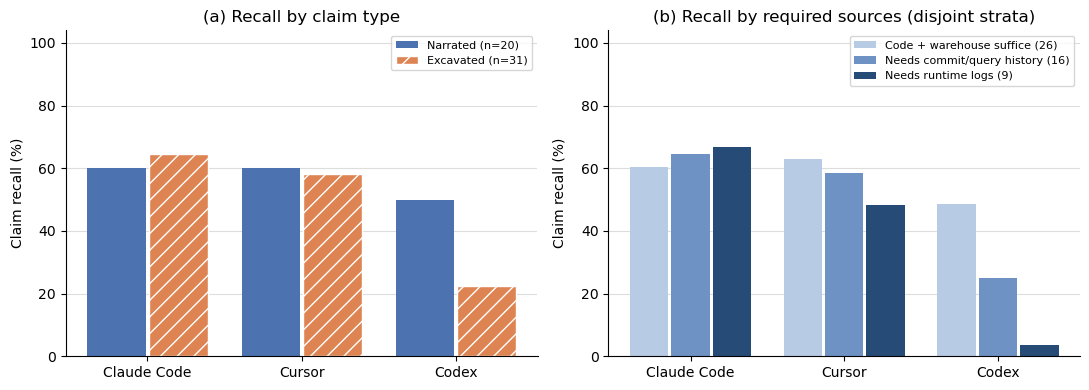

panel (a): [('Claude Code', 60.0, 64.5), ('Cursor', 60.0, 58.1), ('Codex', 50.0, 22.6)]
panel (b): [('Claude Code', [60.3, 64.6, 66.7]), ('Cursor', [62.8, 58.3, 48.1]), ('Codex', [48.7, 25.0, 3.7])]


In [5]:
# Figure 2, redrawn from the data
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
narr = [c for c in CLAIMS if NARR[c]=='narrated']; exc = [c for c in CLAIMS if NARR[c]=='excavated']
def stratum(c):
    h = CM[c]['requires_history']
    return 'logs' if 'logs' in h else ('hist' if h else 'none')
groups = {g: [c for c in CLAIMS if stratum(c)==g] for g in ['none','hist','logs']}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(3); names = [s[0] for s in SYS]
a = axes[0]
a.bar(x-0.2, [recall(r, narr) for _, r in SYS], 0.38, label=f'Narrated (n={len(narr)})', color='#4C72B0')
a.bar(x+0.2, [recall(r, exc) for _, r in SYS], 0.38, label=f'Excavated (n={len(exc)})', color='#DD8452', hatch='//', edgecolor='white')
a.set_title('(a) Recall by claim type')
shades = ['#B7CBE4','#6E92C4','#274B77']
b = axes[1]
for i, (g, lab) in enumerate(zip(['none','hist','logs'], ['Code + warehouse suffice (26)','Needs commit/query history (16)','Needs runtime logs (9)'])):
    b.bar(x+(i-1)*0.27, [recall(r, groups[g]) for _, r in SYS], 0.25, label=lab, color=shades[i])
b.set_title('(b) Recall by required sources (disjoint strata)')
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(names); ax.set_ylim(0, 104); ax.set_ylabel('Claim recall (%)')
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False); ax.yaxis.grid(True, color='#DDDDDD'); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print('panel (a):', [(n, round(recall(r, narr),1), round(recall(r, exc),1)) for n, r in SYS])
print('panel (b):', [(n, [round(recall(r, groups[g]),1) for g in ['none','hist','logs']]) for n, r in SYS])

In [6]:
# App C category tables: counts per tag family
print('narration:', {k: sum(1 for c in CLAIMS if NARR[c]==k) for k in ['narrated','excavated']})
flags = {'commit': 0, 'query': 0, 'logs': 0}
for c in CLAIMS:
    for f in CM[c]['requires_history']: flags[f] += 1
print('source flags:', flags)
print('disjoint strata:', {g: len(v) for g, v in groups.items()})
for key in ['shape', 'business_segment', 'temporal']:
    print(key + ':', dict(sorted(collections.Counter(CM[c][key] for c in CLAIMS).items(), key=lambda kv: -kv[1])))

narration: {'narrated': 20, 'excavated': 31}
source flags: {'commit': 14, 'query': 6, 'logs': 9}
disjoint strata: {'none': 26, 'hist': 16, 'logs': 9}
shape: {'Computed quantity': 12, 'Temporal era': 10, 'Absence': 9, 'Reconciliation': 9, 'Mechanism': 6, 'Multi-source join': 3, 'Other': 2}
business_segment: {'ML & recommendations': 15, 'Orders, payments & fraud': 11, 'Catalog & customers': 10, 'Revenue & reporting': 10, 'Pipelines & scheduling': 5}
temporal: {'Point-in-time': 29, 'Temporal — historical reconstruction': 19, 'Temporal — current-state, dated': 3}


In [7]:
# Tables G3-G5: recall by shape / segment / temporal (categories with n<5 omitted, as in the paper)
for key in ['shape', 'business_segment', 'temporal']:
    print('--', key)
    cats = {}
    for c in CLAIMS: cats.setdefault(CM[c][key], []).append(c)
    for k, v in sorted(cats.items(), key=lambda kv: -len(kv[1])):
        if len(v) < 5: continue
        row = [recall(r, v) for _, r in SYS]
        pooled = 100*sum(M[b][c]=='correct' for b in BOOKS for c in v)/(9*len(v))
        print(f'{k:28s} n={len(v):2d}  {row[0]:5.1f} {row[1]:5.1f} {row[2]:5.1f}  pooled {pooled:5.1f}')

-- shape
Computed quantity            n=12   55.6  50.0  13.9  pooled  39.8
Temporal era                 n=10   53.3  43.3  23.3  pooled  40.0
Absence                      n= 9   74.1  70.4  48.1  pooled  64.2
Reconciliation               n= 9   59.3  59.3  40.7  pooled  53.1
Mechanism                    n= 6   61.1  55.6  27.8  pooled  48.1
-- business_segment
ML & recommendations         n=15   60.0  53.3  35.6  pooled  49.6
Orders, payments & fraud     n=11   84.8  78.8  48.5  pooled  70.7
Catalog & customers          n=10   60.0  50.0  26.7  pooled  45.6
Revenue & reporting          n=10   56.7  63.3  26.7  pooled  48.9
Pipelines & scheduling       n= 5   40.0  40.0  20.0  pooled  33.3
-- temporal
Point-in-time                n=29   60.9  62.1  43.7  pooled  55.6
Temporal — historical reconstruction n=19   61.4  54.4  21.1  pooled  45.6


In [8]:
# App F stability table: per-pass recall and spread per run
for b in BOOKS:
    raw = [V['books'][b][f'pass{p}']['claim_recall'] for p in range(1, 6)]
    print(f'{b:7s} ' + ' / '.join(f'{100*x:.1f}' for x in raw) + f'   spread {100*(max(raw)-min(raw)):.1f}')

cc_r1   72.5 / 70.6 / 70.6 / 70.6 / 72.5   spread 2.0
cc_r2   58.8 / 60.8 / 58.8 / 58.8 / 58.8   spread 2.0
cc_r3   58.8 / 58.8 / 56.9 / 58.8 / 56.9   spread 2.0
cur_r1  56.9 / 51.0 / 56.9 / 56.9 / 56.9   spread 5.9
cur_r2  56.9 / 56.9 / 56.9 / 56.9 / 56.9   spread 0.0
cur_r3  62.7 / 62.7 / 62.7 / 62.7 / 62.7   spread 0.0
cx_r1   33.3 / 33.3 / 35.3 / 33.3 / 33.3   spread 2.0
cx_r2   29.4 / 31.4 / 31.4 / 31.4 / 27.5   spread 3.9
cx_r3   31.4 / 35.3 / 35.3 / 35.3 / 35.3   spread 3.9


## Bootstrap confidence intervals (App. G)


In [9]:
# Bootstrap 95% CIs for Table 2 mean recall (claim-level, 10,000 resamples, seed 0)
import json, random
from collections import Counter
_d = json.load(open("results/verdicts.json"))["books"]
_ORDER = ["contradicted", "missing", "partial", "correct"]
def _maj(vs):
    c = Counter(vs); top = max(c.values())
    return min([k for k, n in c.items() if n == top], key=_ORDER.index)
_ids = sorted(_d["cc_r1"]["pass1"]["verdicts"].keys())
_bm = {b: {cid: _maj([p[f"pass{i}"]["verdicts"][cid] for i in range(1, 6)]) for cid in _ids}
       for b, p in _d.items()}
def _mean(prefix, subset):
    runs = [f"{prefix}_r{i}" for i in (1, 2, 3)]
    return 100 * sum(sum(1 for c in subset if _bm[r][c] == "correct") / len(subset) for r in runs) / 3
for _p, _exp in (("cc", 62.7), ("cur", 58.8), ("cx", 33.3)):
    assert abs(round(_mean(_p, _ids), 1) - _exp) < 0.05, (_p, _mean(_p, _ids))
random.seed(0)
_boots = {p: [] for p in ("cc", "cur", "cx")}
for _ in range(10000):
    s = [random.choice(_ids) for _ in _ids]
    for p in _boots: _boots[p].append(_mean(p, s))
_paper = {"cc": (52.9, 72.5), "cur": (48.4, 69.3), "cx": (22.2, 44.4)}
for _p, _name in (("cc", "Claude Code"), ("cur", "Cursor"), ("cx", "Codex")):
    v = sorted(_boots[_p]); lo, hi = round(v[250], 1), round(v[9749], 1)
    print(f"{_name}: mean {_mean(_p, _ids):.1f}, 95% CI [{lo}, {hi}]")
    assert (lo, hi) == _paper[_p], (_p, lo, hi)
print("all CI values match App. G")


Claude Code: mean 62.7, 95% CI [52.9, 72.5]
Cursor: mean 58.8, 95% CI [48.4, 69.3]
Codex: mean 33.3, 95% CI [22.2, 44.4]
all CI values match App. G
